# **3. MODEL TRAINING**

This is the final notebook for our project. In this notebook, we're gonna create the full ML pipeline that we create to build a prediction model. First, we're gonna preprocess the dataset by encoding it with appropriate encoders, then we're gonna apply SMOTE to balance the dataset and finally train on different models. Then we're gonna select the model with best performance and build a prediction system around it

#### **3.1 Importing Libraries**

The following libraries are required for this notebook

1. Pandas
2. Numpy
3. Matplotlib
4. Seaborn
5. Scikit-learn
    1. OneHotEncoder
    2. OrdinalEncoder
    3. Train-Test Split
    4. Decision Tree
    5. Logistic Regression
    6. Random Forest
    7. Gradient Boosting
    8. Accuracy Score
    9. Precision Score
    10. Recall Score
    11. F1 Score
    12. ROC-AUC Score
    13. Precision Recall Curve
    14. Confusion Matrix
    15. Column Transformer
    16. Extra Trees
6. ImbalancedLearn
    1. SMOTE
    2. Pipeline
    3. Balanced Random Forest
7. XGBoost
8. CatBoost
9. LightGBM
10. Joblib
11. JSON

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, precision_recall_curve
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
import joblib
import json

#### **3.2 Loading The Dataset**

In this step, we're gonna import the new dataset that we had exported in the last notebook

In [2]:
df = pd.read_csv("../data/new_data.csv")
df.columns

Index(['AccidentArea', 'Sex', 'MaritalStatus', 'Age', 'Fault',
       'VehicleCategory', 'VehiclePrice', 'FraudFound_P', 'Deductible',
       'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim',
       'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder',
       'PoliceReportFiled', 'AgentType', 'NumberOfSuppliments',
       'AddressChange_Claim', 'NumberOfCars', 'BasePolicy', 'MonthDelay',
       'DayDelay', 'WeekDelay', 'NoWitnessNoPoliceReport'],
      dtype='str')

#### **3.3 Data Preprocessing**

Before we train the ML models, we need to preprocess the data. This includes splitting them into training and testing sets and applying encoding on them

##### **3.3.1 Splitting The Data**

Firstly, we're gonna split the data into training and testing set. For this, scikit-learn has a library which we're gonna use

**3.3.1.1 Seperating The Target Variable**

In [3]:
X = df.drop("FraudFound_P", axis=1)
y = df["FraudFound_P"]

**3.3.1.2 Applying The Train/Test Split**

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

##### **3.3.2 Feature Encoding**

In this step, we're gonna encode all our data before passing it through ML pipeline. Here is our encoding strategy:

1. Ordinal columns: Ordinal Encoding
2. Binary columns: Ordinal Encoding
3. Numerical columns: Passthrough
4. Categorical columns: One-hot Encoding

**3.3.2.1 Separating All Columns**

In [5]:
ordinal_cols = ["VehiclePrice", "Days_Policy_Accident", "Days_Policy_Claim", "PastNumberOfClaims", "AgeOfVehicle", "AgeOfPolicyHolder", "NumberOfCars", "NumberOfSuppliments", "AddressChange_Claim"]

In [6]:
binary_cols = [col for col in X_train.columns if X_train[col].nunique() == 2 and col not in ordinal_cols]

In [7]:
cat_cols = ["VehicleCategory", "BasePolicy"]

In [8]:
num_cols = X_train.select_dtypes(include=np.number).columns.drop(ordinal_cols).tolist()

**3.3.2.2 Checking All Columns**

Now, we'll quickly check all columns before proceeding

In [9]:
print("Categorical Columns:", cat_cols)
print("Numerical Columns:", num_cols)
print("Ordinal Columns:", ordinal_cols)
print("Binary Columns:", binary_cols)

Categorical Columns: ['VehicleCategory', 'BasePolicy']
Numerical Columns: ['Age', 'Deductible', 'DriverRating', 'MonthDelay', 'DayDelay', 'WeekDelay']
Ordinal Columns: ['VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'NumberOfCars', 'NumberOfSuppliments', 'AddressChange_Claim']
Binary Columns: ['AccidentArea', 'Sex', 'MaritalStatus', 'Fault', 'PoliceReportFiled', 'AgentType', 'NoWitnessNoPoliceReport']


##### **3.3.3 Creating Preprocessor**

Now we're gonna create a preprocessor using Column Transformer. What it will do is that perform all encoding that we require when any data is passed through it

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "ord_bin",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
            ordinal_cols + binary_cols,
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_cols
        )
    ],
    remainder="passthrough"
)

As we can see, we applied Ordinal Encoding on the ordinal and binary columns, One-Hot Encoding on all categorical columns and passed through the rest

#### **3.4 Model Training**

In this step, we're gonna train all the models. As discussed earlier, first we'll train all models and then choose the best one. So here, all the training will be done and then the evaluation metrics will be printed

##### **3.4.1 Testing on Default Parameters**

Firstly, we're gonna test on the default parameters of the models. This is to check how each model performs on their default settings in other words

**3.4.1.1 Selecting The Models**

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42, n_jobs=-1),
    "CatBoost": CatBoostClassifier(verbose=0, random_seed=42),
    "LightGBM": LGBMClassifier(random_state=42),
    "Balanced Random Forest": BalancedRandomForestClassifier(random_state=42, n_jobs=-1)
}

**3.4.1.2 Training The Models**

In this step, we're gonna prepare a pipeline before we train our ML model. The pipeline will work like this:

1. Data is first preprocessed with the preprocessor we created earlier
2. SMOTE is then applied on the data to handle class imbalance
3. Model is then selected

After all this, the model is trained and it makes predictions

In [12]:
results = []

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessing', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

d:\Projects\Automobile Insurance Fraud Detection\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Info] Number of positive: 11366, number of negative: 11366
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004584 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6216
[LightGBM] [Info] Number of data points in the train set: 22732, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


d:\Projects\Automobile Insurance Fraud Detection\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


**3.4.1.3 Saving The Results**

In [13]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.647682,0.123939,0.820225,0.215339
1,Decision Tree,0.894371,0.162679,0.191011,0.175711
4,XGBoost,0.940397,0.472222,0.095506,0.158879
6,CatBoost,0.941722,0.541667,0.073034,0.128713
5,Extra Trees,0.937086,0.350000,0.078652,0.128440
7,LightGBM,0.942715,0.647059,0.061798,0.112821
8,Balanced Random Forest,0.939073,0.392857,0.061798,0.106796
2,Random Forest,0.939073,0.375000,0.050562,0.089109
3,Gradient Boosting,0.942384,0.700000,0.039326,0.074468


##### **3.4.2 Testing with Hyperparameter Tuning**

Now that we have tested on default parameters, we'll now test by tuning some hyperparameters. This might even give us better results than what we got on default parameters.

**3.4.2.1 Selecting The Models**

In [14]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        C=0.5,
        penalty="l2",
        solver="liblinear",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=10,
        criterion="gini",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features="sqrt",
        bootstrap=True,
        n_jobs=-1,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        subsample=0.8,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.2,
        reg_alpha=0.5,
        reg_lambda=1.0,
        eval_metric="logloss",
        random_state=42
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features="sqrt",
        bootstrap=False,
        n_jobs=-1,
        random_state=42
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=5,
        loss_function="Logloss",
        eval_metric="F1",
        verbose=0,
        random_seed=42
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1.0,
        class_weight="balanced",
        random_state=42
    ),
    "Balanced Random Forest": BalancedRandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features="sqrt",
        bootstrap=True,
        sampling_strategy="auto",
        replacement=False,
        n_jobs=-1,
        random_state=42
    )
}

**3.4.2.2 Training The Models**

In [15]:
results = []

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessing', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

d:\Projects\Automobile Insurance Fraud Detection\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[LightGBM] [Info] Number of positive: 11366, number of negative: 11366
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006952 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6216
[LightGBM] [Info] Number of data points in the train set: 22732, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

d:\Projects\Automobile Insurance Fraud Detection\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


**3.4.2.3 Saving The Results**

In [16]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
5,Extra Trees,0.771523,0.143454,0.578652,0.229911
1,Decision Tree,0.849338,0.161369,0.370787,0.224872
0,Logistic Regression,0.648675,0.125530,0.831461,0.218128
8,Balanced Random Forest,0.910927,0.206452,0.179775,0.192192
2,Random Forest,0.911258,0.200000,0.168539,0.182927
4,XGBoost,0.944040,0.800000,0.067416,0.124352
7,LightGBM,0.943377,0.733333,0.061798,0.113990
3,Gradient Boosting,0.943377,0.769231,0.056180,0.104712
6,CatBoost,0.943046,1.000000,0.033708,0.065217


As we can see, the F1 score has increased in some of the models. This is definitely an improvement over the default parameters

**3.4.3 Choosing The Models**

As we can see, XGBoost, CatBoost, LightGBM and Gradient Boosting show very high precision in contrast to their low recall. There is a chance that this is highly unlikely so we'll assume for this project that it is a case of overfitting. The low accuracy of Logistic Regression with just 64.8% is also not in our favor. So we're gonna choose hyperparameter tuned Decision Tree, Random Forest, Balanced Random Forest and Extra Trees to proceed with

##### **3.4.3 Testing with Threshold Tuning**

By default, the threshold of each model is 0.50. What we're gonna do here is that we'll be testing the evaluation metrics of the 4 chosen models on different thresholds. That way we can finally make our final choice on the best model 

**3.4.3.1 Choosing The Models**

In [17]:
models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=10,
        criterion="gini",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features="sqrt",
        bootstrap=True,
        n_jobs=-1,
        random_state=42
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features="sqrt",
        bootstrap=False,
        n_jobs=-1,
        random_state=42
    ),
    "Balanced Random Forest": BalancedRandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features="sqrt",
        bootstrap=True,
        sampling_strategy="auto",
        replacement=False,
        n_jobs=-1,
        random_state=42
    )
}

**3.4.3.2 Training The Models**

In [18]:
thresholds = np.arange(0.10, 0.91, 0.05)

all_results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])
    pipeline.fit(X_train, y_train)
    y_probs = pipeline.predict_proba(X_test)[:, 1]
    for threshold in thresholds:
        y_pred_thresh = (y_probs >= threshold).astype(int)
        accuracy = accuracy_score(y_test, y_pred_thresh)
        precision = precision_score(y_test, y_pred_thresh, zero_division=0)
        recall = recall_score(y_test, y_pred_thresh, zero_division=0)
        f1 = f1_score(y_test, y_pred_thresh, zero_division=0)
        roc_auc = roc_auc_score(y_test, y_probs)
        all_results.append({
            "Model": name,
            "Threshold": round(threshold, 2),
            "Accuracy": round(accuracy, 4),
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1 Score": round(f1, 4),
            "ROC-AUC": round(roc_auc, 4)
        })

**3.4.3.3 Saving The Results**

In [19]:
results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    by=["Model", "F1 Score"],
    ascending=[True, False]
)

print(results_df.to_string(index=False))

                 Model  Threshold  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Balanced Random Forest       0.40    0.8682     0.1995  0.4101    0.2684   0.8093
Balanced Random Forest       0.35    0.8321     0.1730  0.4888    0.2555   0.8093
Balanced Random Forest       0.30    0.7821     0.1542  0.6011    0.2454   0.8093
Balanced Random Forest       0.25    0.7281     0.1432  0.7247    0.2391   0.8093
Balanced Random Forest       0.20    0.6785     0.1372  0.8427    0.2360   0.8093
Balanced Random Forest       0.45    0.8904     0.2000  0.2865    0.2356   0.8093
Balanced Random Forest       0.15    0.6464     0.1298  0.8764    0.2261   0.8093
Balanced Random Forest       0.10    0.6066     0.1231  0.9270    0.2174   0.8093
Balanced Random Forest       0.50    0.9109     0.2065  0.1798    0.1922   0.8093
Balanced Random Forest       0.55    0.9272     0.2375  0.1067    0.1473   0.8093
Balanced Random Forest       0.60    0.9338     0.2250  0.0506    0.0826   0.8093
Balanced Random 

As we can see, for Random Forest, Balanced Random Forest and Decision Tree, threshold of 0.40 seems to giving the best results while for Extra Trees a threshold of 0.55 seems to be the best. Out of these 4, it is hard to choose just 1 model as most of them have almost the same F1-score and varied Recalls. So we're gonna implement a system in our frontend where the user will be able to choose the model they'd like to predict with

#### **3.5 Final Results**

Here, we're just gonna display the final results (best scores) of each of the 4 models that we think are performing the best on our dataset

**Random Forest**

- Accuracy:
- Precision:
- Recall:
- F1-score:
- ROC-AUC Score:

**Balanced Random Forest**

- Accuracy:
- Precision:
- Recall:
- F1-score:
- ROC-AUC Score:

**Extra Trees**

- Accuracy:
- Precision:
- Recall:
- F1-score:
- ROC-AUC Score:

**Decision Tree**

- Accuracy:
- Precision:
- Recall:
- F1-score:
- ROC-AUC Score:

#### **3.6 Plotting Graphs for Models**

In this step, we're gonna plot graphs for the evaluation metrics and performance of each model. This will help us understand the final results of the models in even better way. Along with that, we're also gonna create individual prediction pipelines for each model that we're gonna export in the future to use

##### **3.6.1 Random Forest**

C:\Users\aaryan\AppData\Local\Temp\ipykernel_18448\2185728295.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


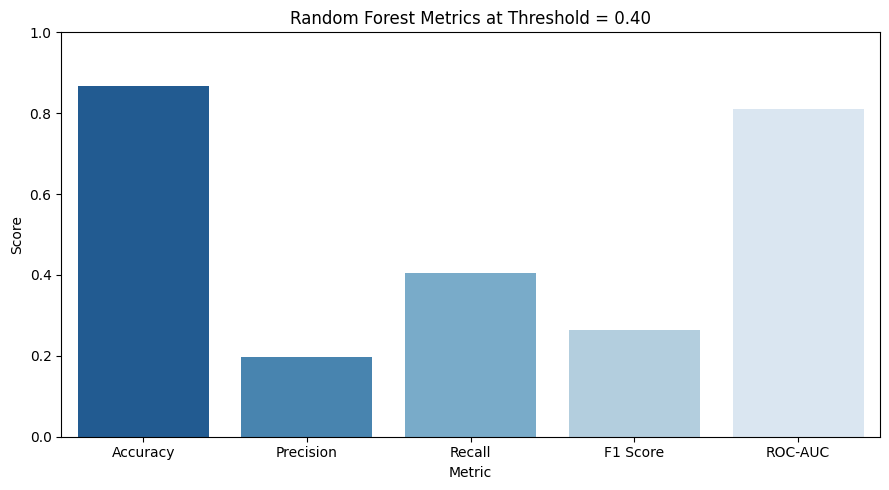

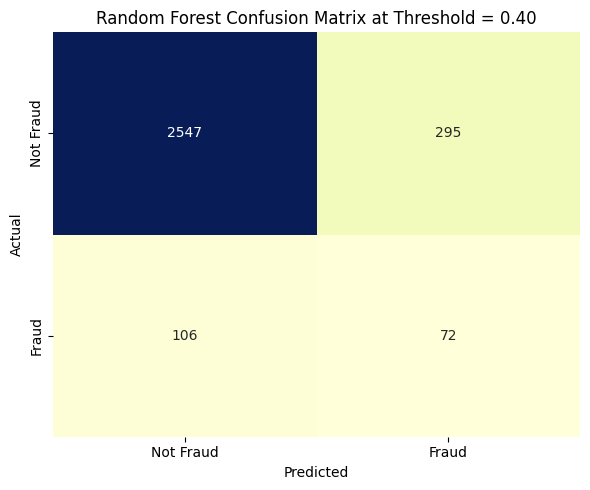

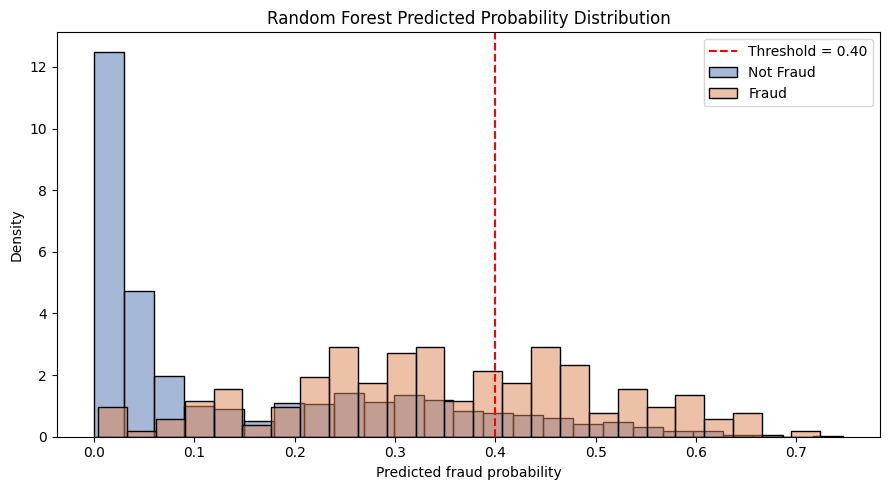

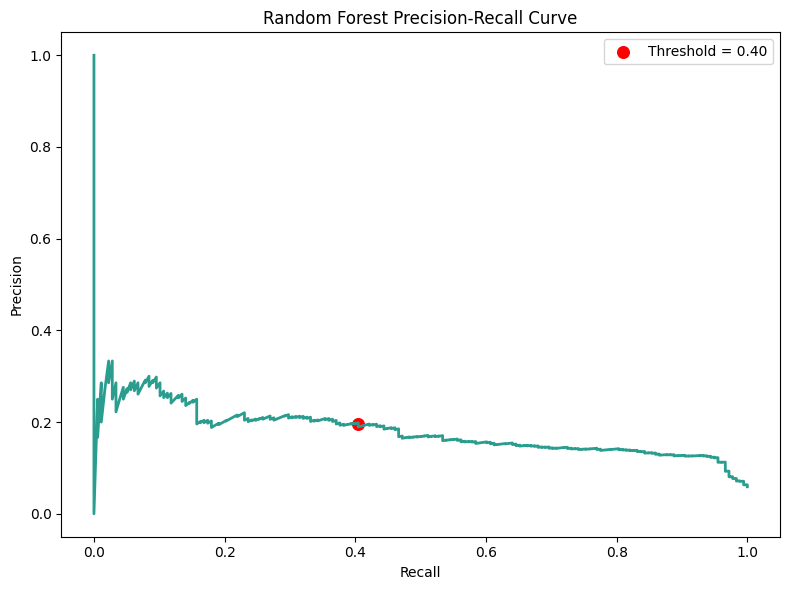

C:\Users\aaryan\AppData\Local\Temp\ipykernel_18448\2185728295.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_importances, x="Importance", y="Feature", palette="viridis")


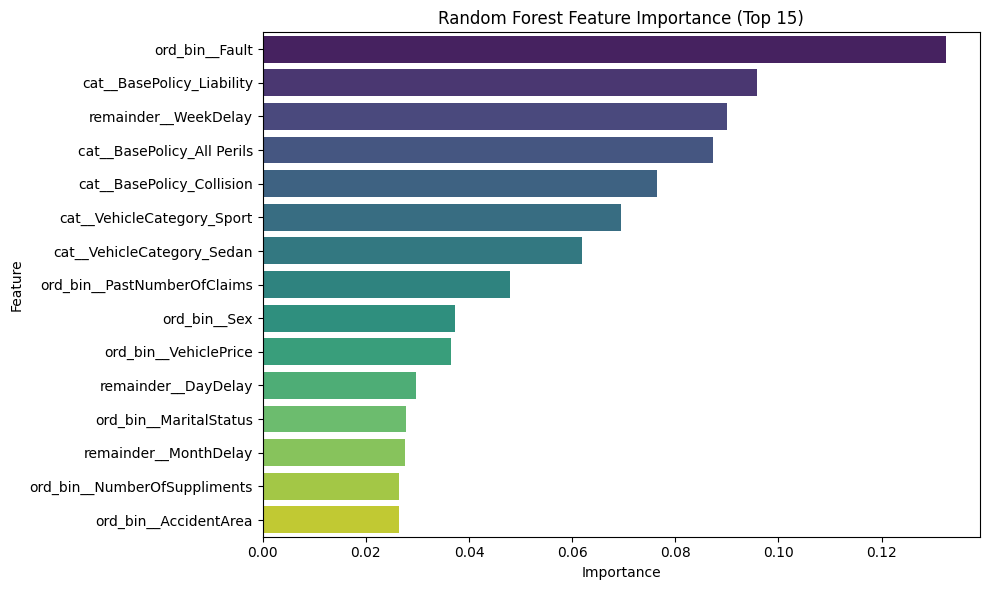

In [30]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features="sqrt",
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

rf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', rf_model)
])

rf_pipeline.fit(X_train, y_train)

rf_probs = rf_pipeline.predict_proba(X_test)[:, 1]
rf_threshold = 0.40
rf_pred = (rf_probs >= rf_threshold).astype(int)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)
rf_roc_auc = roc_auc_score(y_test, rf_probs)

metric_values = {
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1 Score": rf_f1,
    "ROC-AUC": rf_roc_auc,
}

plt.figure(figsize=(9, 5))
sns.barplot(
    x=list(metric_values.keys()),
    y=list(metric_values.values()),
    palette="Blues_r"
 )
plt.ylim(0, 1)
plt.title("Random Forest Metrics at Threshold = 0.40")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    cbar=False,
    xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"]
 )
plt.title("Random Forest Confusion Matrix at Threshold = 0.40")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
sns.histplot(rf_probs[y_test == 0], bins=25, color="#4C72B0", label="Not Fraud", stat="density", alpha=0.5)
sns.histplot(rf_probs[y_test == 1], bins=25, color="#DD8452", label="Fraud", stat="density", alpha=0.5)
plt.axvline(rf_threshold, color="red", linestyle="--", label=f"Threshold = {rf_threshold:.2f}")
plt.title("Random Forest Predicted Probability Distribution")
plt.xlabel("Predicted fraud probability")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, rf_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color="#2A9D8F", linewidth=2)
plt.scatter(rf_recall, rf_precision, color="red", s=70, label=f"Threshold = {rf_threshold:.2f}")
plt.title("Random Forest Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

rf_feature_names = rf_pipeline.named_steps["preprocessing"].get_feature_names_out()
rf_importances = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_pipeline.named_steps["model"].feature_importances_
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importances, x="Importance", y="Feature", palette="viridis")
plt.title("Random Forest Feature Importance (Top 15)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

##### **3.6.2 Balanced Random Forest**

C:\Users\aaryan\AppData\Local\Temp\ipykernel_18448\1909347832.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


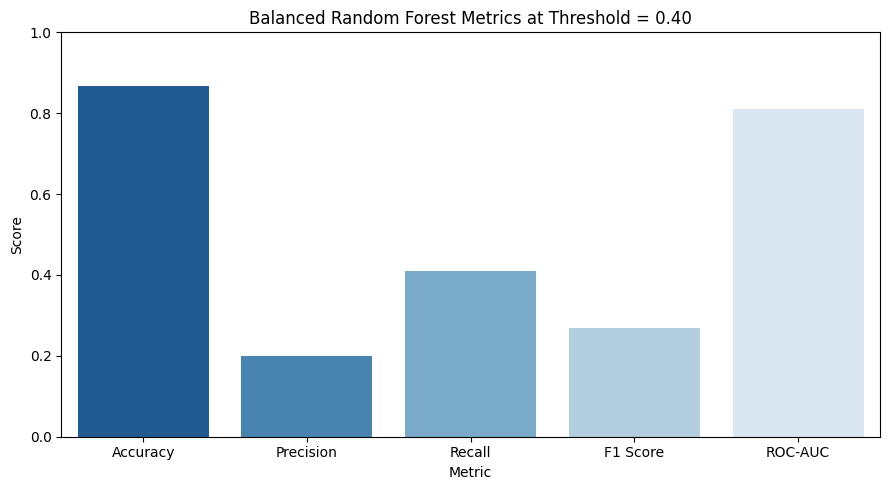

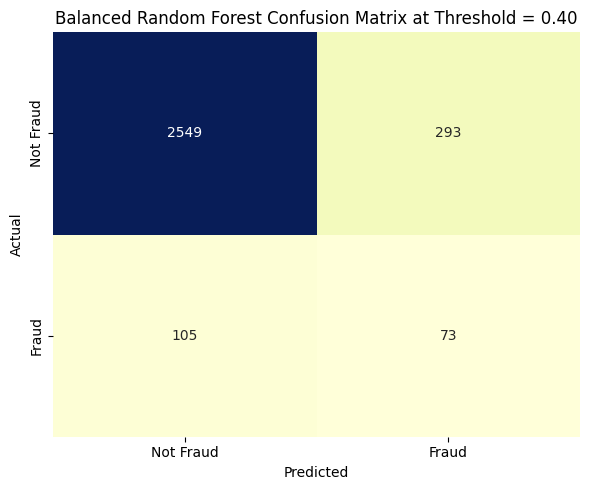

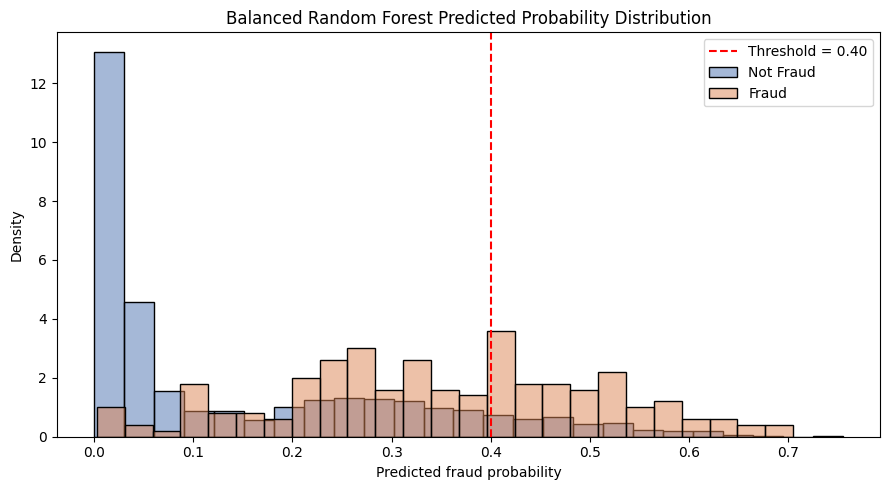

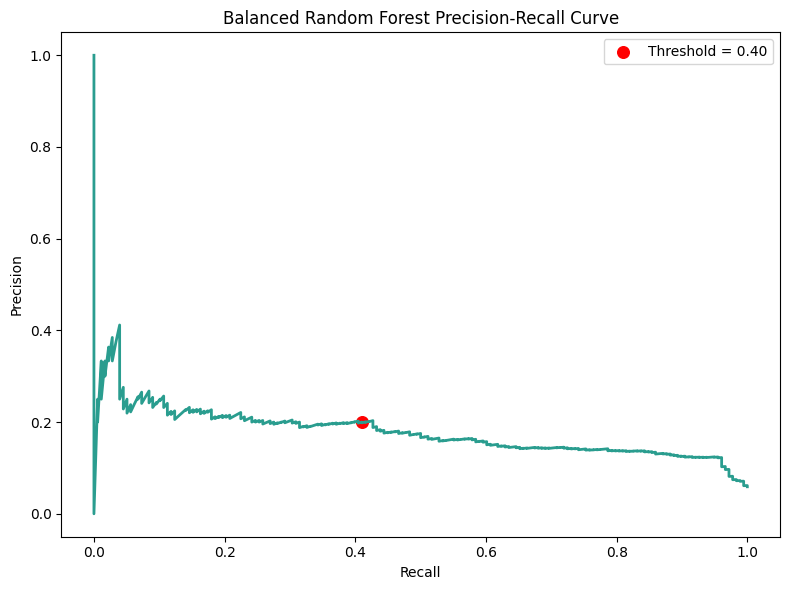

C:\Users\aaryan\AppData\Local\Temp\ipykernel_18448\1909347832.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=brf_importances, x="Importance", y="Feature", palette="viridis")


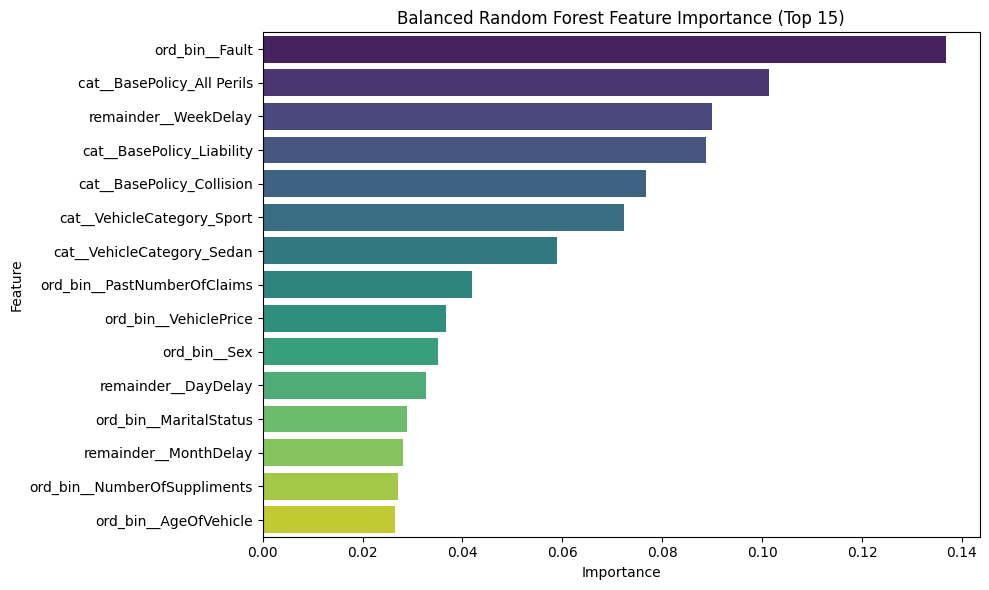

In [29]:
brf_model = BalancedRandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features="sqrt",
        bootstrap=True,
        sampling_strategy="auto",
        replacement=False,
        n_jobs=-1,
        random_state=42
)

brf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', brf_model)
])

brf_pipeline.fit(X_train, y_train)

brf_probs = brf_pipeline.predict_proba(X_test)[:, 1]
brf_threshold = 0.40
brf_pred = (brf_probs >= brf_threshold).astype(int)

brf_accuracy = accuracy_score(y_test, brf_pred)
brf_precision = precision_score(y_test, brf_pred, zero_division=0)
brf_recall = recall_score(y_test, brf_pred, zero_division=0)
brf_f1 = f1_score(y_test, brf_pred, zero_division=0)
brf_roc_auc = roc_auc_score(y_test, brf_probs)

metric_values = {
    "Accuracy": brf_accuracy,
    "Precision": brf_precision,
    "Recall": brf_recall,
    "F1 Score": brf_f1,
    "ROC-AUC": brf_roc_auc,
}

plt.figure(figsize=(9, 5))
sns.barplot(
    x=list(metric_values.keys()),
    y=list(metric_values.values()),
    palette="Blues_r"
 )
plt.ylim(0, 1)
plt.title("Balanced Random Forest Metrics at Threshold = 0.40")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, brf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    cbar=False,
    xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"]
 )
plt.title("Balanced Random Forest Confusion Matrix at Threshold = 0.40")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
sns.histplot(brf_probs[y_test == 0], bins=25, color="#4C72B0", label="Not Fraud", stat="density", alpha=0.5)
sns.histplot(brf_probs[y_test == 1], bins=25, color="#DD8452", label="Fraud", stat="density", alpha=0.5)
plt.axvline(brf_threshold, color="red", linestyle="--", label=f"Threshold = {brf_threshold:.2f}")
plt.title("Balanced Random Forest Predicted Probability Distribution")
plt.xlabel("Predicted fraud probability")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, brf_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color="#2A9D8F", linewidth=2)
plt.scatter(brf_recall, brf_precision, color="red", s=70, label=f"Threshold = {brf_threshold:.2f}")
plt.title("Balanced Random Forest Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

brf_feature_names = brf_pipeline.named_steps["preprocessing"].get_feature_names_out()
brf_importances = pd.DataFrame({
    "Feature": brf_feature_names,
    "Importance": brf_pipeline.named_steps["model"].feature_importances_
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=brf_importances, x="Importance", y="Feature", palette="viridis")
plt.title("Balanced Random Forest Feature Importance (Top 15)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

##### **3.6.3 Extra Trees**

C:\Users\aaryan\AppData\Local\Temp\ipykernel_18448\971605197.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


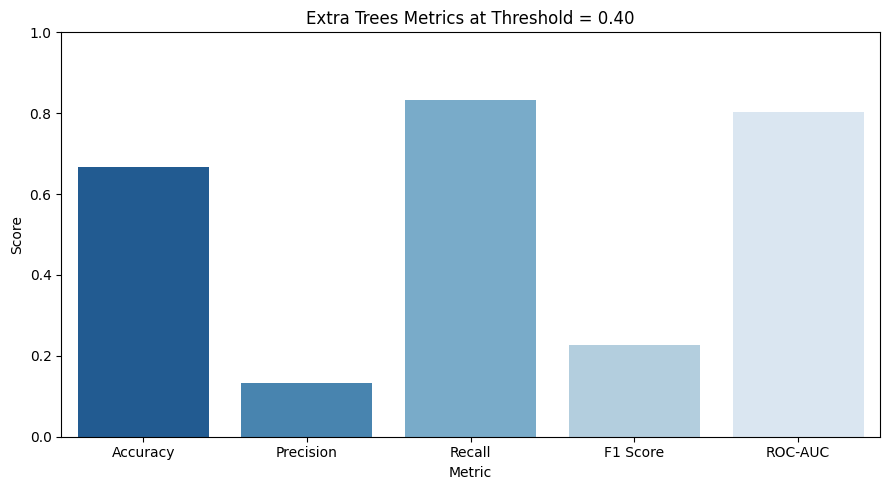

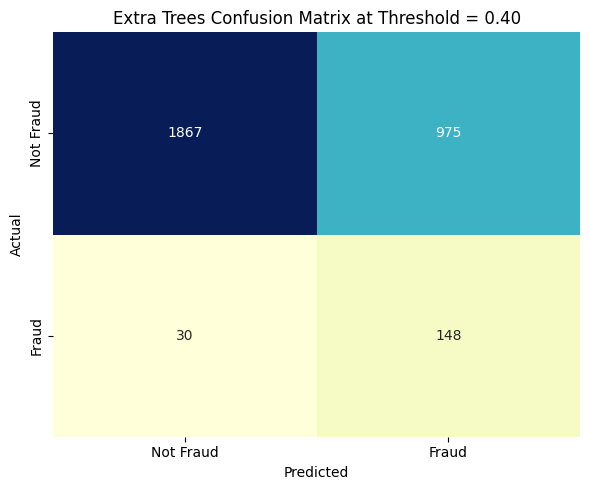

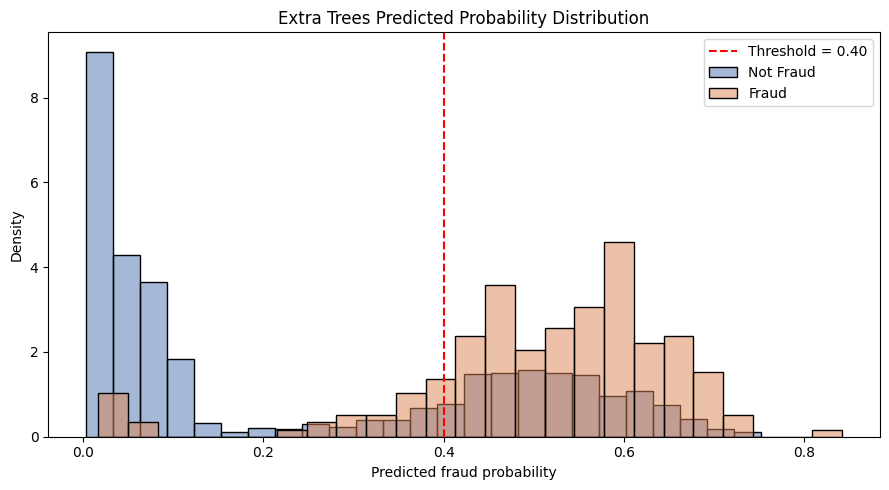

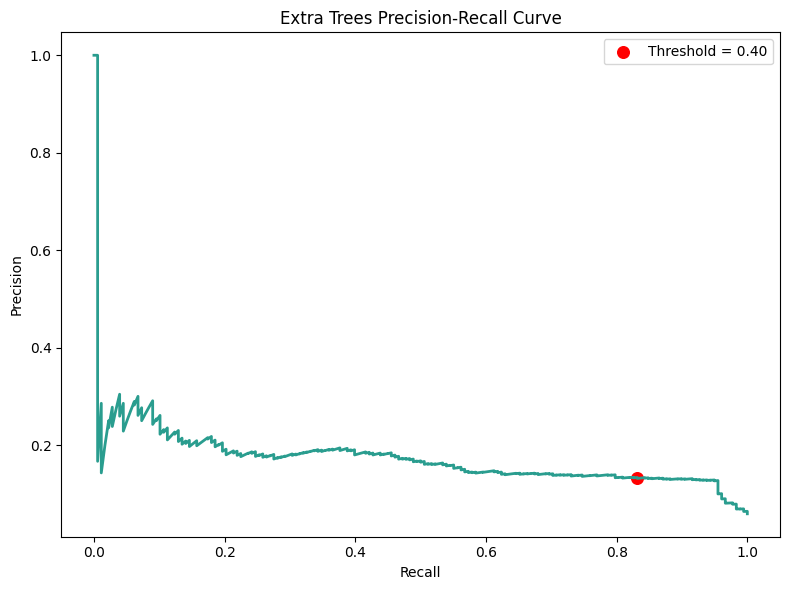

C:\Users\aaryan\AppData\Local\Temp\ipykernel_18448\971605197.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=et_importances, x="Importance", y="Feature", palette="viridis")


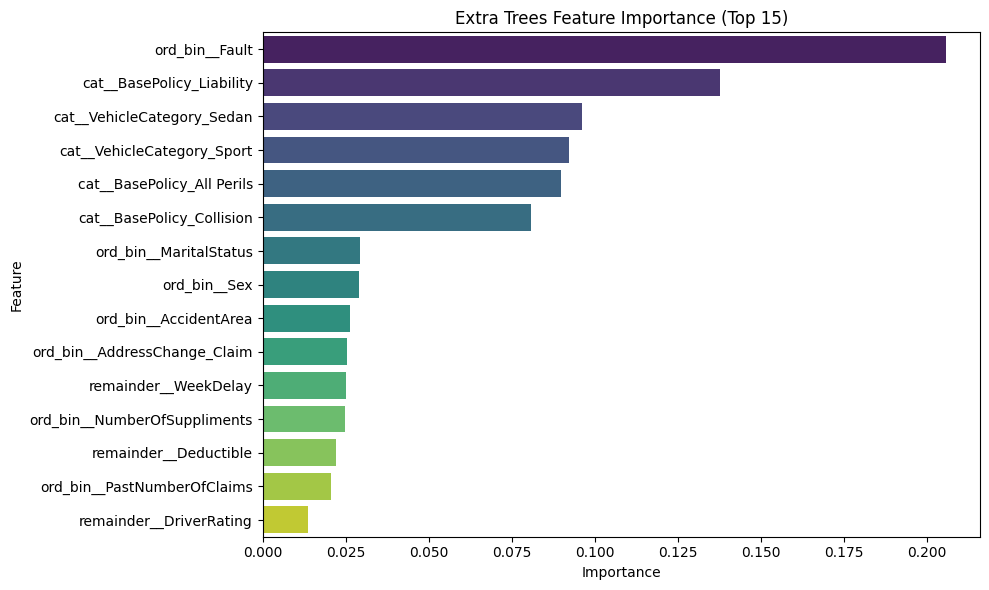

In [28]:
et_model = ExtraTreesClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features="sqrt",
        bootstrap=False,
        n_jobs=-1,
        random_state=42
    )

et_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', et_model)
])

et_pipeline.fit(X_train, y_train)

et_probs = et_pipeline.predict_proba(X_test)[:, 1]
et_threshold = 0.40
et_pred = (et_probs >= et_threshold).astype(int)

et_accuracy = accuracy_score(y_test, et_pred)
et_precision = precision_score(y_test, et_pred, zero_division=0)
et_recall = recall_score(y_test, et_pred, zero_division=0)
et_f1 = f1_score(y_test, et_pred, zero_division=0)
et_roc_auc = roc_auc_score(y_test, et_probs)

metric_values = {
    "Accuracy": et_accuracy,
    "Precision": et_precision,
    "Recall": et_recall,
    "F1 Score": et_f1,
    "ROC-AUC": et_roc_auc,
}

plt.figure(figsize=(9, 5))
sns.barplot(
    x=list(metric_values.keys()),
    y=list(metric_values.values()),
    palette="Blues_r"
 )
plt.ylim(0, 1)
plt.title("Extra Trees Metrics at Threshold = 0.40")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, et_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    cbar=False,
    xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"]
 )
plt.title("Extra Trees Confusion Matrix at Threshold = 0.40")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
sns.histplot(et_probs[y_test == 0], bins=25, color="#4C72B0", label="Not Fraud", stat="density", alpha=0.5)
sns.histplot(et_probs[y_test == 1], bins=25, color="#DD8452", label="Fraud", stat="density", alpha=0.5)
plt.axvline(et_threshold, color="red", linestyle="--", label=f"Threshold = {et_threshold:.2f}")
plt.title("Extra Trees Predicted Probability Distribution")
plt.xlabel("Predicted fraud probability")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, et_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color="#2A9D8F", linewidth=2)
plt.scatter(et_recall, et_precision, color="red", s=70, label=f"Threshold = {et_threshold:.2f}")
plt.title("Extra Trees Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

et_feature_names = et_pipeline.named_steps["preprocessing"].get_feature_names_out()
et_importances = pd.DataFrame({
    "Feature": et_feature_names,
    "Importance": et_pipeline.named_steps["model"].feature_importances_
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=et_importances, x="Importance", y="Feature", palette="viridis")
plt.title("Extra Trees Feature Importance (Top 15)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

##### **3.6.4 Decision Tree**

C:\Users\aaryan\AppData\Local\Temp\ipykernel_18448\76213938.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


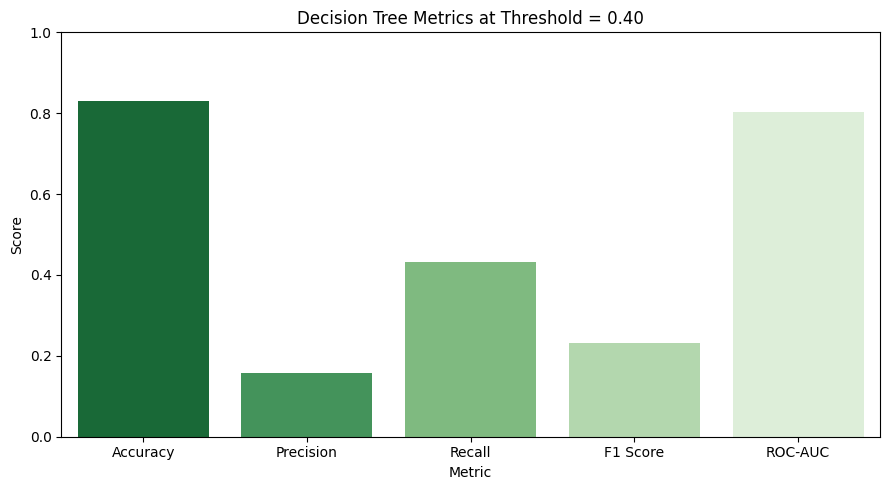

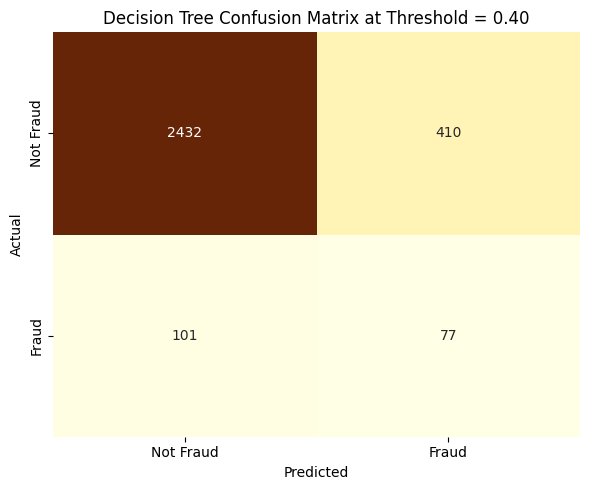

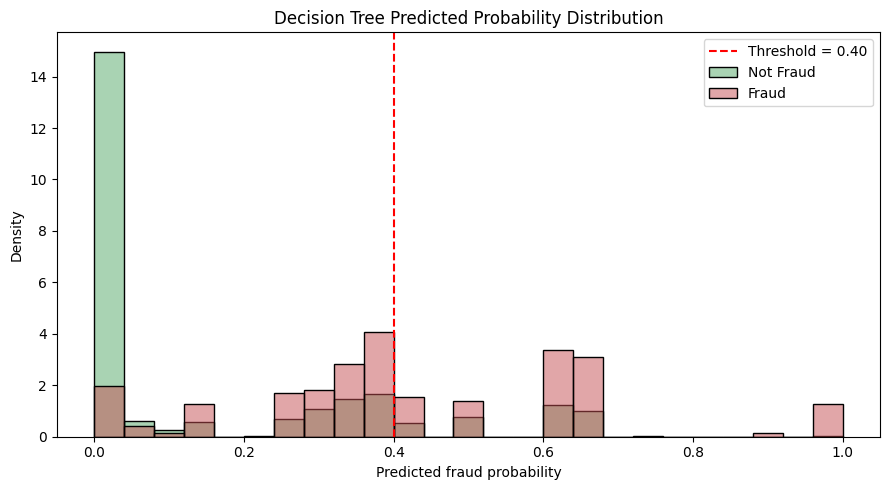

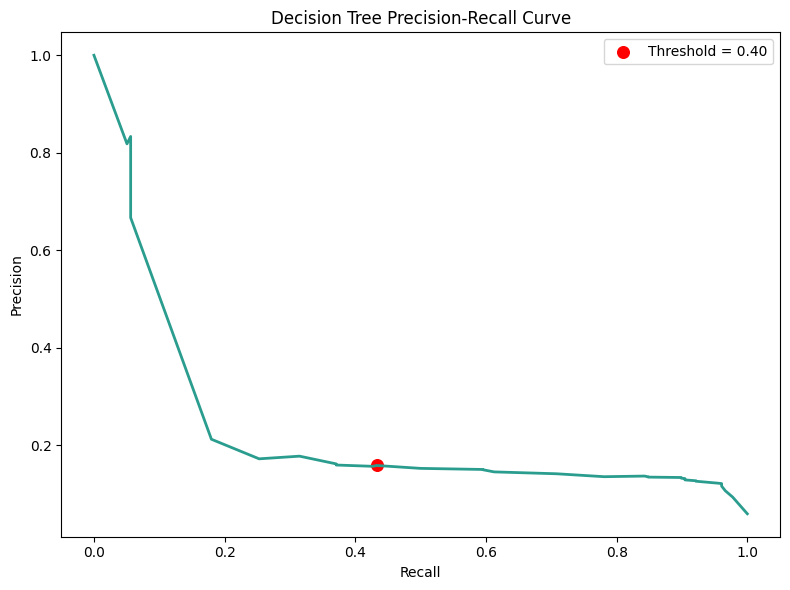

C:\Users\aaryan\AppData\Local\Temp\ipykernel_18448\76213938.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dt_importances, x="Importance", y="Feature", palette="viridis")


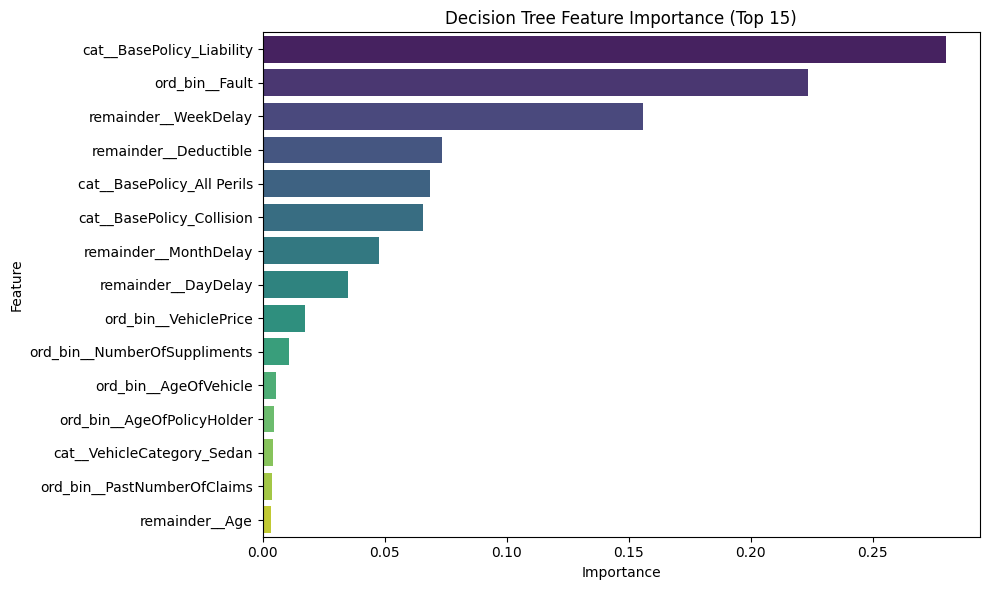

In [27]:
dt_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    criterion="gini",
    random_state=42
)

dt_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', dt_model)
])

dt_pipeline.fit(X_train, y_train)

dt_probs = dt_pipeline.predict_proba(X_test)[:, 1]
dt_threshold = 0.40
dt_pred = (dt_probs >= dt_threshold).astype(int)

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred, zero_division=0)
dt_recall = recall_score(y_test, dt_pred, zero_division=0)
dt_f1 = f1_score(y_test, dt_pred, zero_division=0)
dt_roc_auc = roc_auc_score(y_test, dt_probs)

metric_values = {
    "Accuracy": dt_accuracy,
    "Precision": dt_precision,
    "Recall": dt_recall,
    "F1 Score": dt_f1,
    "ROC-AUC": dt_roc_auc,
}

plt.figure(figsize=(9, 5))
sns.barplot(
    x=list(metric_values.keys()),
    y=list(metric_values.values()),
    palette="Greens_r"
 )
plt.ylim(0, 1)
plt.title("Decision Tree Metrics at Threshold = 0.40")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlOrBr",
    cbar=False,
    xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"]
 )
plt.title("Decision Tree Confusion Matrix at Threshold = 0.40")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
sns.histplot(dt_probs[y_test == 0], bins=25, color="#55A868", label="Not Fraud", stat="density", alpha=0.5)
sns.histplot(dt_probs[y_test == 1], bins=25, color="#C44E52", label="Fraud", stat="density", alpha=0.5)
plt.axvline(dt_threshold, color="red", linestyle="--", label=f"Threshold = {dt_threshold:.2f}")
plt.title("Decision Tree Predicted Probability Distribution")
plt.xlabel("Predicted fraud probability")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, dt_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color="#2A9D8F", linewidth=2)
plt.scatter(dt_recall, dt_precision, color="red", s=70, label=f"Threshold = {dt_threshold:.2f}")
plt.title("Decision Tree Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

dt_feature_names = dt_pipeline.named_steps["preprocessing"].get_feature_names_out()
dt_importances = pd.DataFrame({
    "Feature": dt_feature_names,
    "Importance": dt_pipeline.named_steps["model"].feature_importances_
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=dt_importances, x="Importance", y="Feature", palette="viridis")
plt.title("Decision Tree Feature Importance (Top 15)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#### **3.7 Final Prediction System**

In this step, we're gonna build a function that will act as our main prediction system. In it, user will be able to add values, choose model and get fraud prediction. We're gonna imitate this same function in our frontend as well

In [45]:
def predict_random_forest_fraud(user_input, threshold=0.40):
    expected_columns = X_train.columns.tolist()
    input_data = {column: X_train[column].mode().iloc[0] for column in expected_columns}
    input_data.update(user_input)

    input_df = pd.DataFrame([input_data], columns=expected_columns)

    probability_of_fraud = rf_pipeline.predict_proba(input_df)[:, 1][0]
    prediction = int(probability_of_fraud >= threshold)
    prediction_label = "Fraud" if prediction == 1 else "Not Fraud"

    print(f"Threshold: {threshold:.2f}")
    print(f"Fraud Probability: {probability_of_fraud:.4f}")
    print(f"Prediction: {prediction_label}")

    return {
        "threshold": threshold,
        "fraud_probability": probability_of_fraud,
        "prediction": prediction_label,
    }

sample_user_input = {
    "Age": 45,
    "Month": 1,
    "MonthClaimed": 1,
    "WeekOfMonth": 2,
    "WeekOfMonthClaimed": 3,
    "DayOfWeek": 2,
    "DayOfWeekClaimed": 4,
    "VehiclePrice": "60000+",
    "Days_Policy_Accident": "30+",
    "Days_Policy_Claim": "30+",
    "PastNumberOfClaims": "0",
    "AgeOfVehicle": "2-5",
    "AgeOfPolicyHolder": "40-50",
    "NumberOfCars": "1",
    "NumberOfSuppliments": "0",
    "AddressChange_Claim": "No",
    "VehicleCategory": "Sedan",
    "BasePolicy": "All Perils",
    "MaritalStatus": "Married",
    "AccidentArea": "Urban",
    "Sex": "Male",
    "Fault": "Policy Holder",
    "PoliceReportFiled": "No",
    "AgentType": "External",
    "LessAgeExpensiveVehicle": 0,
    "NoWitnessNoPoliceReport": "No",
    "MonthDelay": 0,
    "DayDelay": 0,
    "WeekDelay": 1
}

prediction_result = predict_random_forest_fraud(sample_user_input, threshold=0.40)
prediction_result

Threshold: 0.40
Fraud Probability: 0.4741
Prediction: Fraud


{'threshold': 0.4,
 'fraud_probability': np.float64(0.47405222598157365),
 'prediction': 'Fraud'}

#### **3.8 Exporting The Models**

In this step, we're gonna export the pipeline of each ML model in our directory. With this, we'll be able to use each model whenever we like to predict the fraud. Our aim with that is gonna be to import it in our backend API which will be used when creating the website

##### **3.8.1 Exporting Random Forest**

In [ ]:
rf_pipeline_deployment = Pipeline([
    ('preprocessing', preprocessor),
    ('model', rf_model)
])

rf_pipeline_deployment.fit(X_train, y_train)

joblib.dump(rf_pipeline_deployment, "output/rf_model.pkl")

['output/rf_model.pkl']

##### **3.8.2 Exporting Balanced Random Forest**

##### **3.8.3 Exporting Extra Trees**

##### **3.8.4 Exporting Decision Tree**

In [ ]:
dt_pipeline_deployment = Pipeline([
    ('preprocessing', preprocessor),
    ('model', dt_model)
])

dt_pipeline_deployment.fit(X_train, y_train)

joblib.dump(dt_pipeline_deployment, "output/dt_model.pkl")

['output/dt_model.pkl']

##### **3.8.5 Exporting Feature Order**

Here we're gonna export the Feature Order. Its important to input the user data in same order as it is present in the training data so thats why we are gonna export this

In [53]:
X_train.columns

Index(['AccidentArea', 'Sex', 'MaritalStatus', 'Age', 'Fault',
       'VehicleCategory', 'VehiclePrice', 'Deductible', 'DriverRating',
       'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims',
       'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'AgentType',
       'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars',
       'BasePolicy', 'MonthDelay', 'DayDelay', 'WeekDelay',
       'NoWitnessNoPoliceReport', 'LessAgeExpensiveVehicle'],
      dtype='str')

In [55]:
feature_list = list(X_train.columns)
with open("output/feature_list.json", "w") as f:
    json.dump(feature_list, f)

##### **3.8.6 Exporting Categorical Features**

In this step, we're gonna export all categorical features. We're doing this because this will help us a lot in the frontend development

In [57]:
cat_features = {}

for col in X.columns:
    cat_features[col] = list(df[col].astype(str).unique())
    
with open("output/cat_features.json", "w") as f:
    json.dump(cat_features, f)

#### **3.9 Notebook Summary**

**Data Preprocessing**

- Created a full data preprocessing function
- Applied ordinal encoding on ordinal and binary columns
- Applied one-hot encoding on categorical columns
- Allowed numerical columns to passthrough

**ML Model Training**

- Created proper ML pipeline that followed:
    1. Encoding
    2. SMOTE 
- Trained 7 total models on default and tuned parameters
- Chose 4 best models to train on different thresholds
- Finally picked the best performing models
- Plotted visualisations for each model
- Exported each model along with feature list and categorical features

**Insights**

- The best performing models were:
    1. Random Forest
    2. Balanced Random Forest
    3. Extra Trees
    4. Decision Tree
- Decision Tree has Base Policy feature as highest in Feature Importance
- With this, our main work of the project is done
- The exported files can be used to build a website